<a href="https://www.kaggle.com/code/lalit7881/e-commerce-sales-data-analysis-eda-99-60?scriptVersionId=346370506" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/products.csv
/kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/clean_final_data.csv
/kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/orders.csv
/kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/customers.csv
/kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/payments.csv


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/erfan4524/e-commerce-sales-data-analysis-and-eda/clean_final_data.csv')

In [4]:
df.head()

,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
0,500001,103695,2025-08-28,2003,4.0,10.0,Gateway,Completed,36.0,Qom,2024-03-05,Regular,USB-C Cable,Accessories,9.0,32.0,32.0
1,500002,107935,2024-05-31,2014,1.0,10.0,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,Backpack,Accessories,42.0,38.0,38.0
2,500003,105141,2025-08-10,2002,1.0,20.0,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,Mechanical Keyboard,Electronics,62.0,50.0,50.0
3,500004,108780,2024-10-11,2012,1.0,10.0,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,Office Chair,Home Office,180.0,162.0,162.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,Phone Case,Accessories,14.0,28.0,28.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49222 entries, 0 to 49221
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          49222 non-null  int64  
 1   CustomerID       49222 non-null  int64  
 2   OrderDate        49222 non-null  object 
 3   ProductID        49222 non-null  int64  
 4   Quantity         49222 non-null  float64
 5   Discount         49222 non-null  float64
 6   PaymentMethod    49222 non-null  object 
 7   Status           49222 non-null  object 
 8   Age              49222 non-null  float64
 9   City             49222 non-null  object 
 10  SignupDate       49222 non-null  object 
 11  CustomerSegment  49222 non-null  object 
 12  ProductName      49222 non-null  object 
 13  Category         49222 non-null  object 
 14  UnitPrice        49222 non-null  float64
 15  Sales            49222 non-null  float64
 16  OrderValue       49222 non-null  float64
dtypes: float64(6

In [6]:
df.describe()

,OrderID,CustomerID,ProductID,Quantity,Discount,Age,UnitPrice,Sales,OrderValue
count,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000,49222.000000
mean,525007.608366,105002.304356,2009.460160,1.881923,7.485576,41.283369,40.286579,69.985576,69.985576
std,14435.345449,2888.912895,5.578603,1.079382,7.754378,13.681355,42.613062,94.483273,94.483273
min,500001.000000,100001.000000,2001.000000,-2.000000,0.000000,18.000000,7.000000,-170.000000,-170.000000
25%,512507.250000,102504.000000,2004.000000,1.000000,0.000000,29.000000,11.000000,17.000000,17.000000
50%,525016.500000,105005.000000,2008.000000,2.000000,5.000000,41.000000,28.000000,38.000000,38.000000
75%,537506.750000,107497.000000,2014.000000,2.000000,10.000000,53.000000,58.000000,84.000000,84.000000
max,550000.000000,110000.000000,2020.000000,5.000000,30.000000,65.000000,260.000000,1300.000000,1300.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

OrderID            0
CustomerID         0
OrderDate          0
ProductID          0
Quantity           0
Discount           0
PaymentMethod      0
Status             0
Age                0
City               0
SignupDate         0
CustomerSegment    0
ProductName        0
Category           0
UnitPrice          0
Sales              0
OrderValue         0
dtype: int64

In [9]:
df.dtypes

OrderID              int64
CustomerID           int64
OrderDate           object
ProductID            int64
Quantity           float64
Discount           float64
PaymentMethod       object
Status              object
Age                float64
City                object
SignupDate          object
CustomerSegment     object
ProductName         object
Category            object
UnitPrice          float64
Sales              float64
OrderValue         float64
dtype: object

In [10]:
df.shape

(49222, 17)

In [11]:
df.columns

Index(['OrderID', 'CustomerID', 'OrderDate', 'ProductID', 'Quantity',
       'Discount', 'PaymentMethod', 'Status', 'Age', 'City', 'SignupDate',
       'CustomerSegment', 'ProductName', 'Category', 'UnitPrice', 'Sales',
       'OrderValue'],
      dtype='object')

In [12]:
df.nunique()

OrderID            49222
CustomerID          9820
OrderDate            912
ProductID             20
Quantity               8
Discount               6
PaymentMethod          4
Status                 3
Age                   48
City                  10
SignupDate          1094
CustomerSegment        3
ProductName           20
Category               6
UnitPrice             20
Sales                290
OrderValue           290
dtype: int64

## EDA


NUMERICAL SUMMARY
           Quantity      Discount           Age     UnitPrice         Sales  \
count  49222.000000  49222.000000  49222.000000  49222.000000  49222.000000   
mean       1.881923      7.485576     41.283369     40.286579     69.985576   
std        1.079382      7.754378     13.681355     42.613062     94.483273   
min       -2.000000      0.000000     18.000000      7.000000   -170.000000   
25%        1.000000      0.000000     29.000000     11.000000     17.000000   
50%        2.000000      5.000000     41.000000     28.000000     38.000000   
75%        2.000000     10.000000     53.000000     58.000000     84.000000   
max        5.000000     30.000000     65.000000    260.000000   1300.000000   

         OrderValue  
count  49222.000000  
mean      69.985576  
std       94.483273  
min     -170.000000  
25%       17.000000  
50%       38.000000  
75%       84.000000  
max     1300.000000  


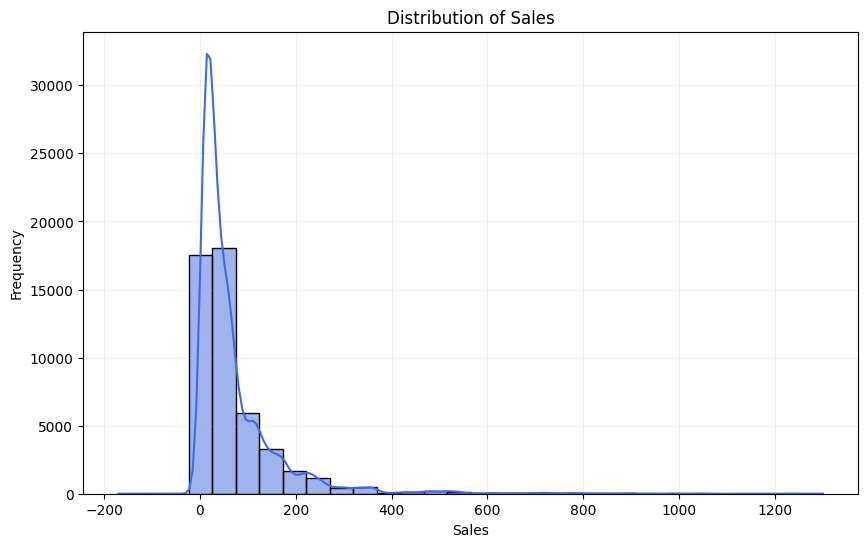

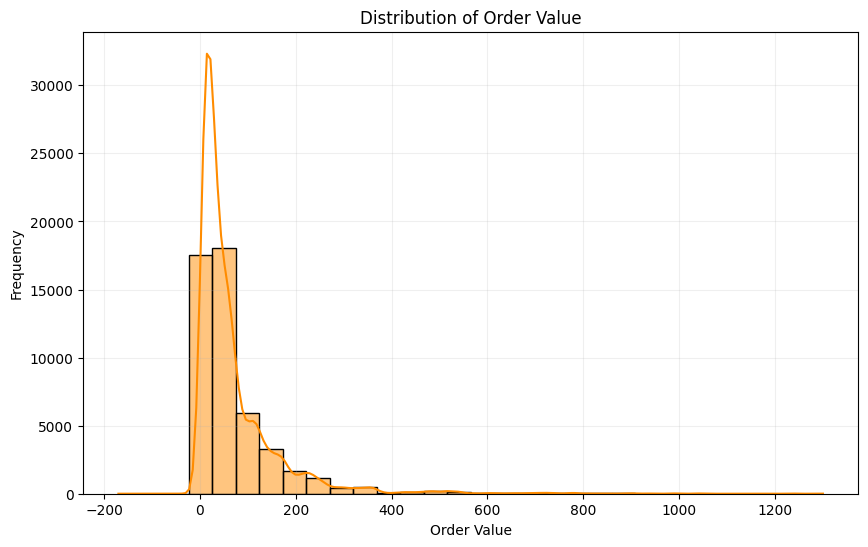

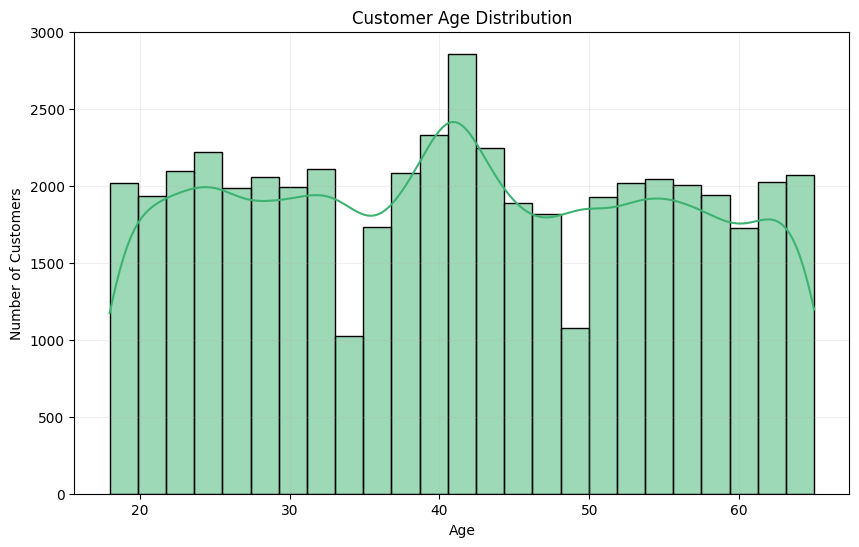

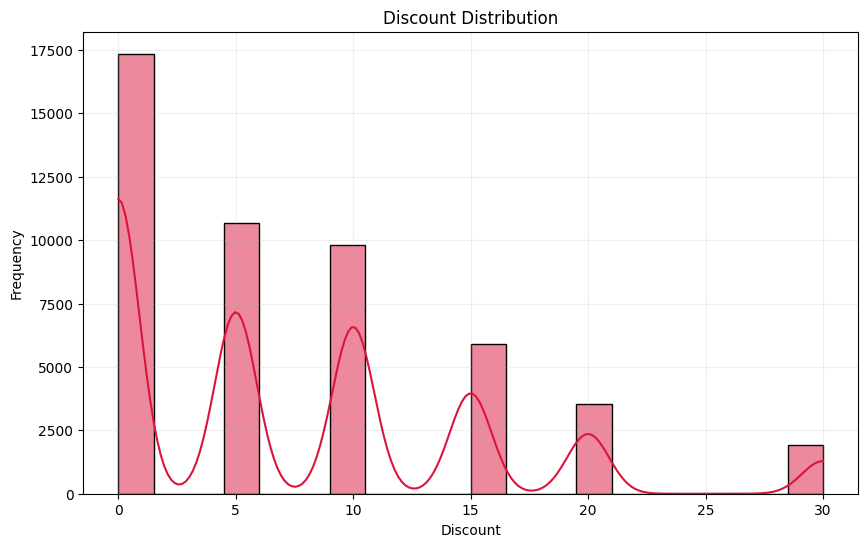

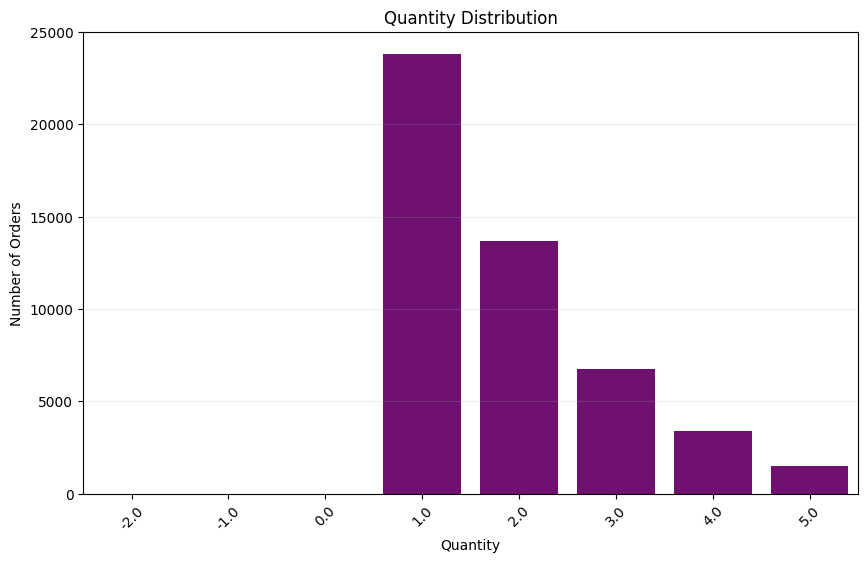

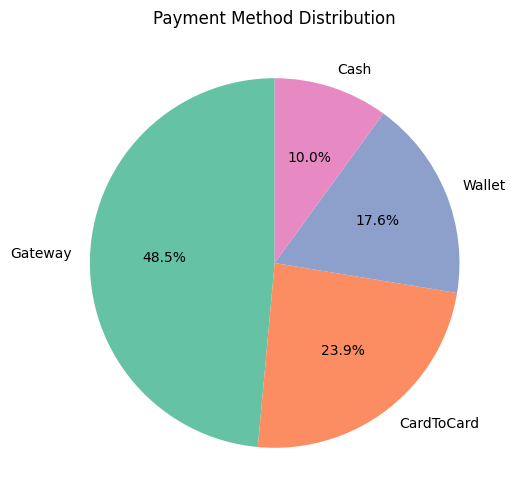

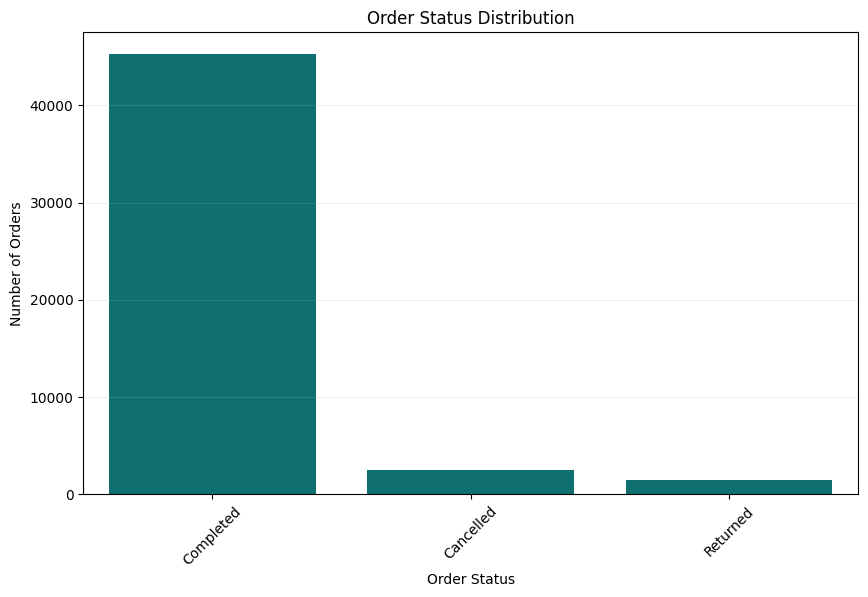

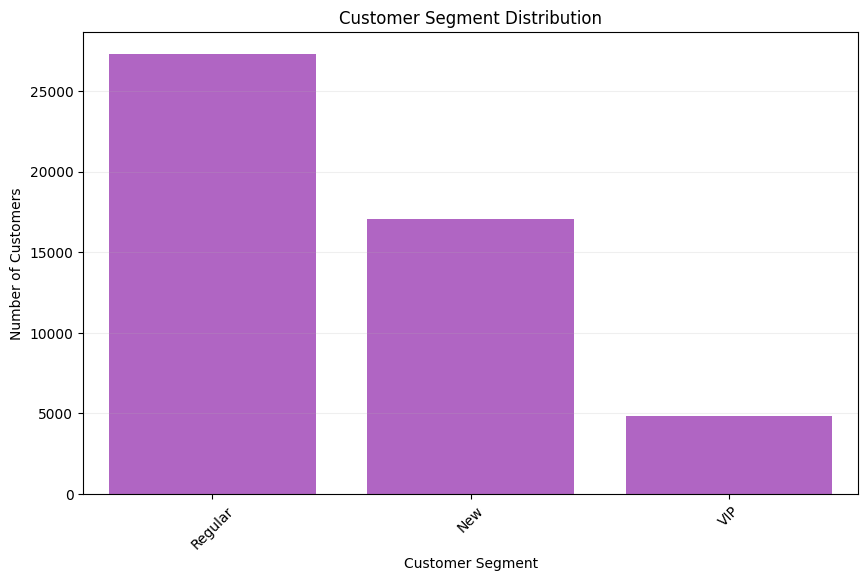

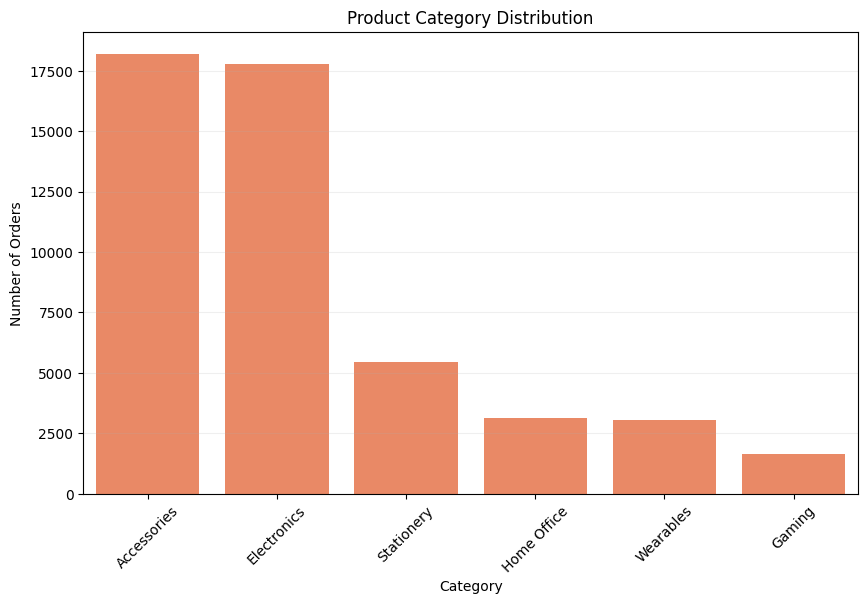

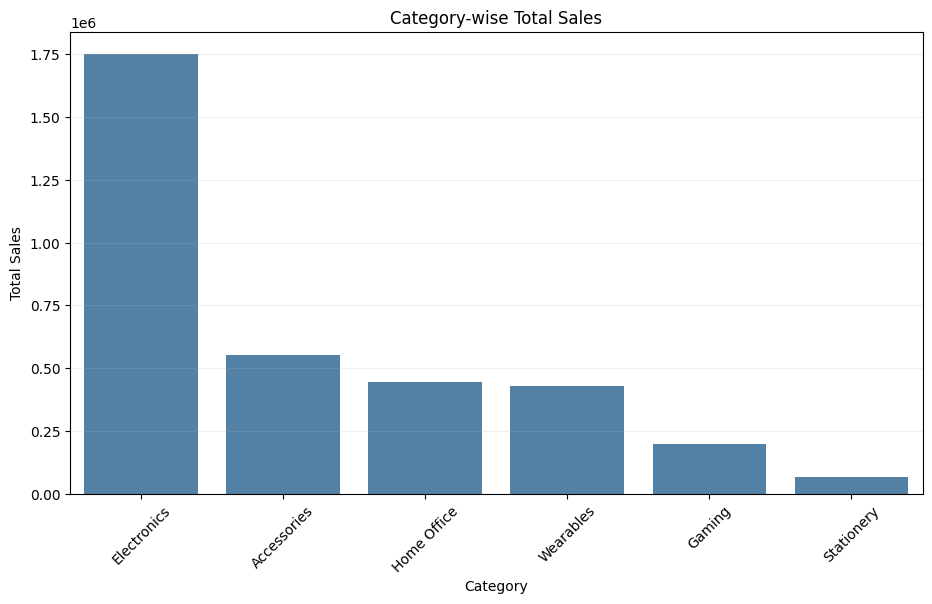

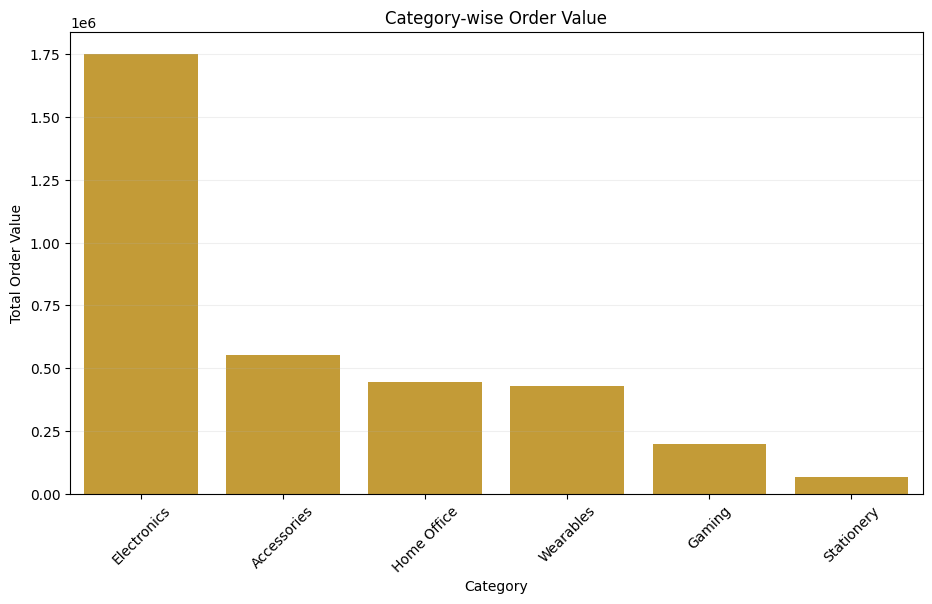

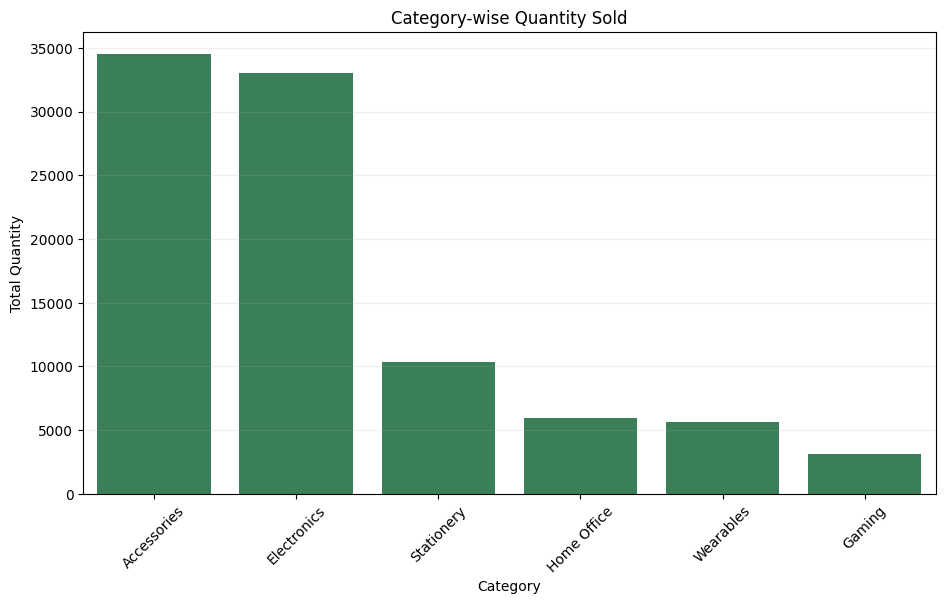

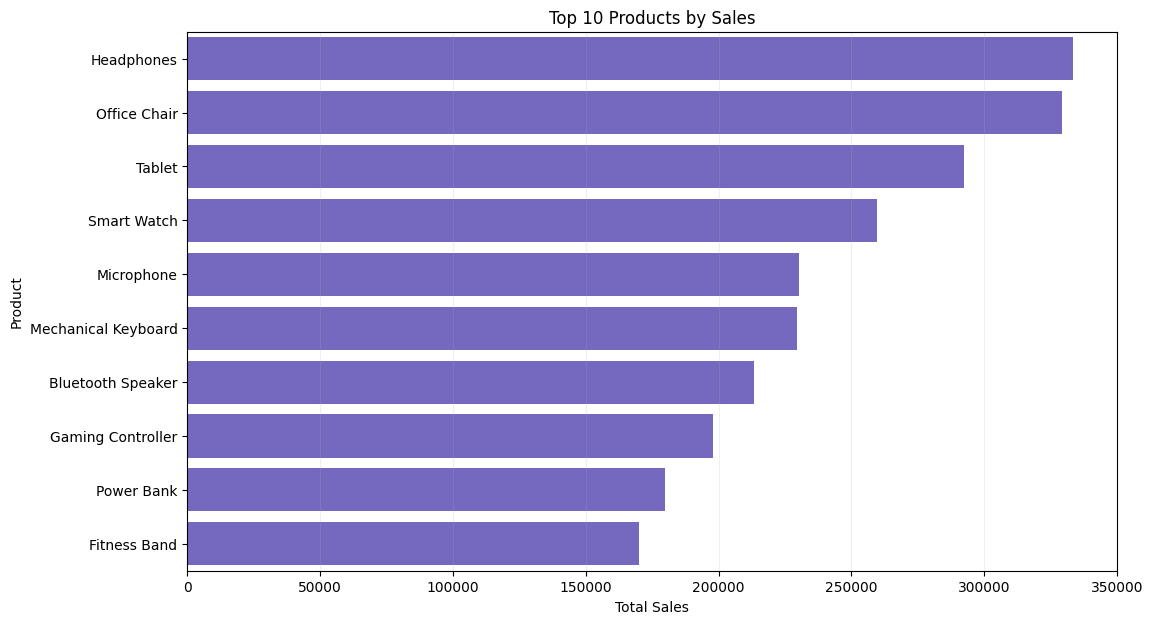

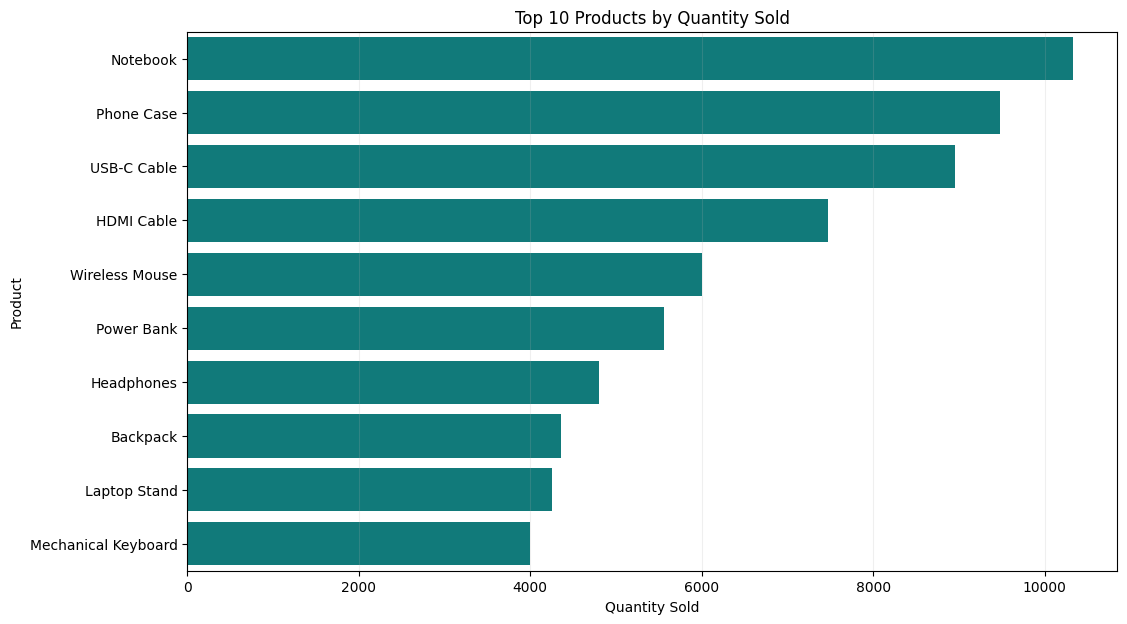

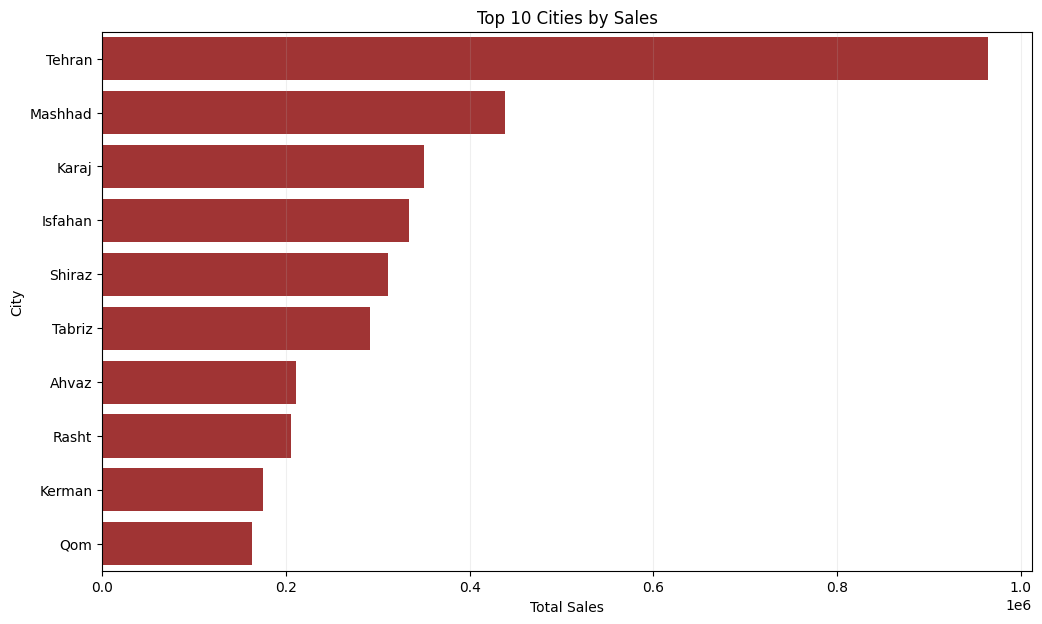

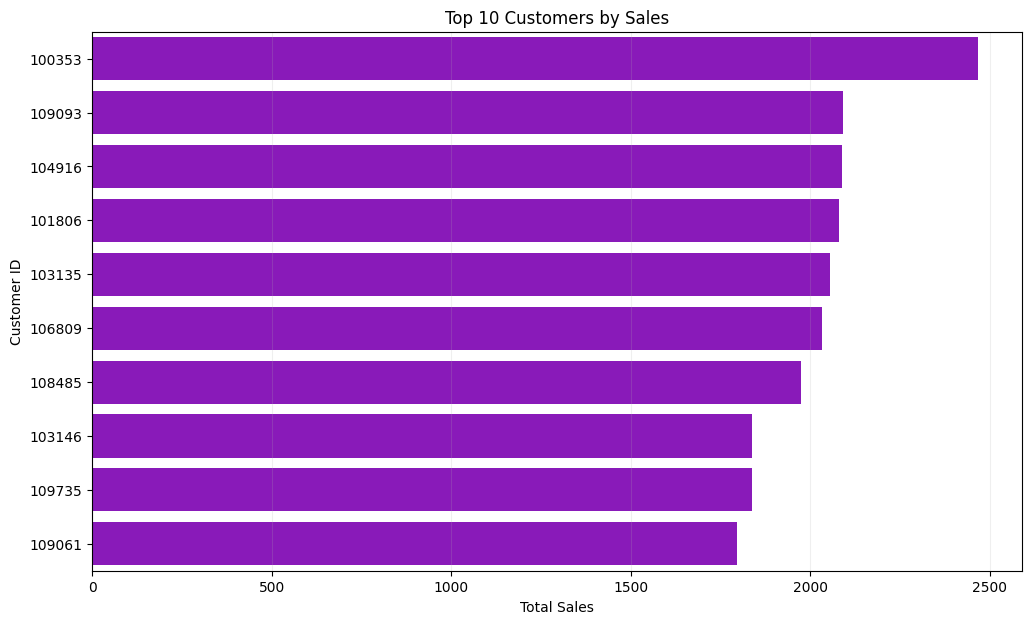

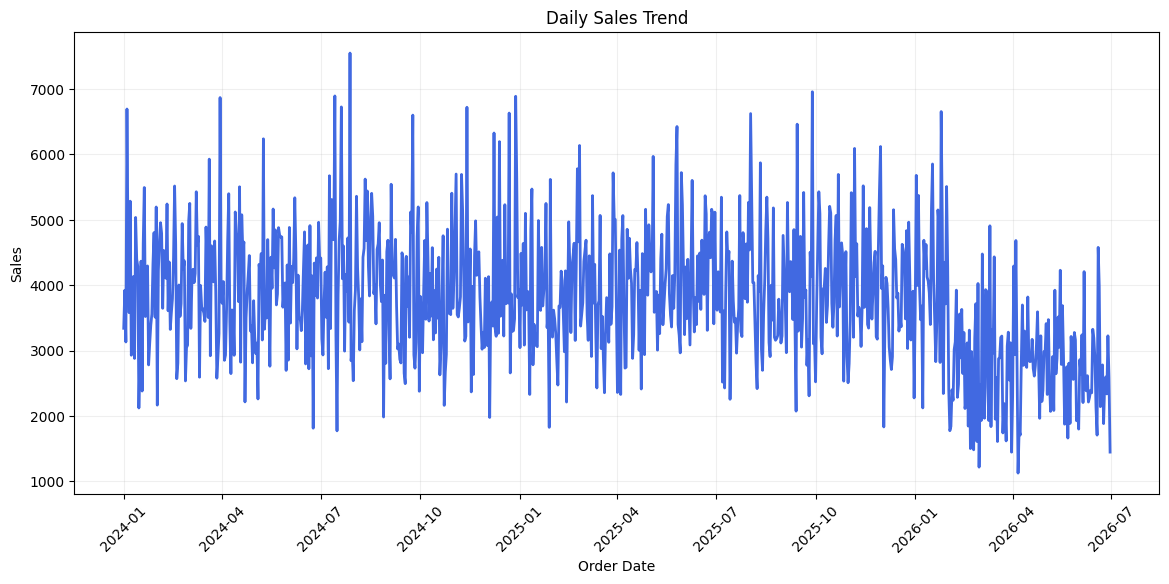

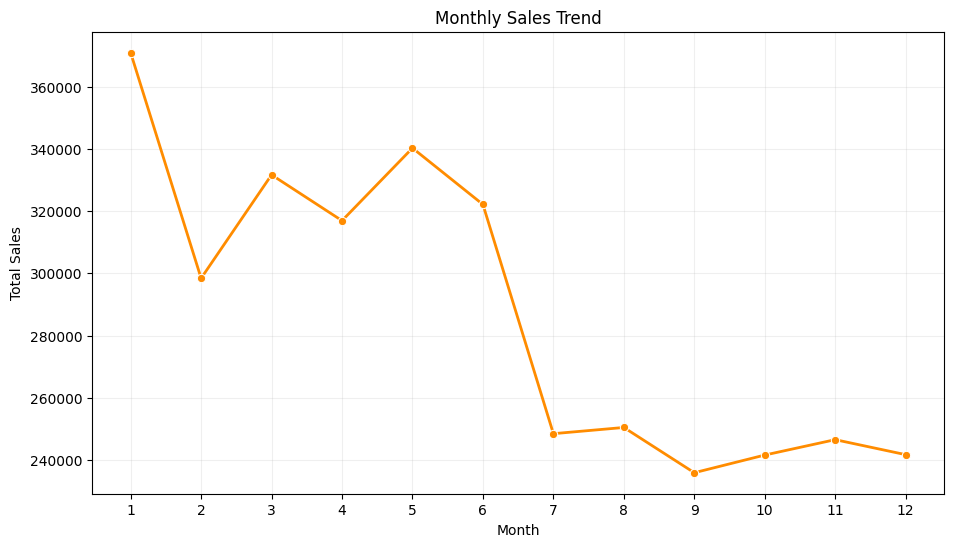

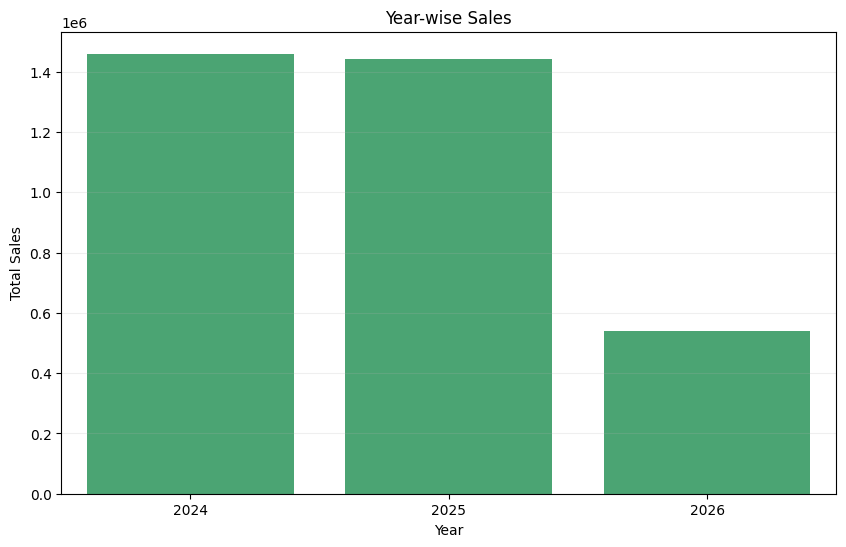

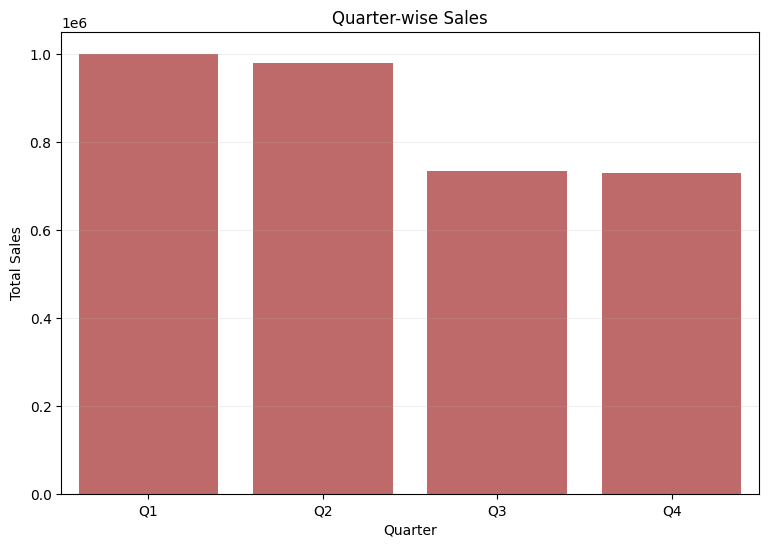

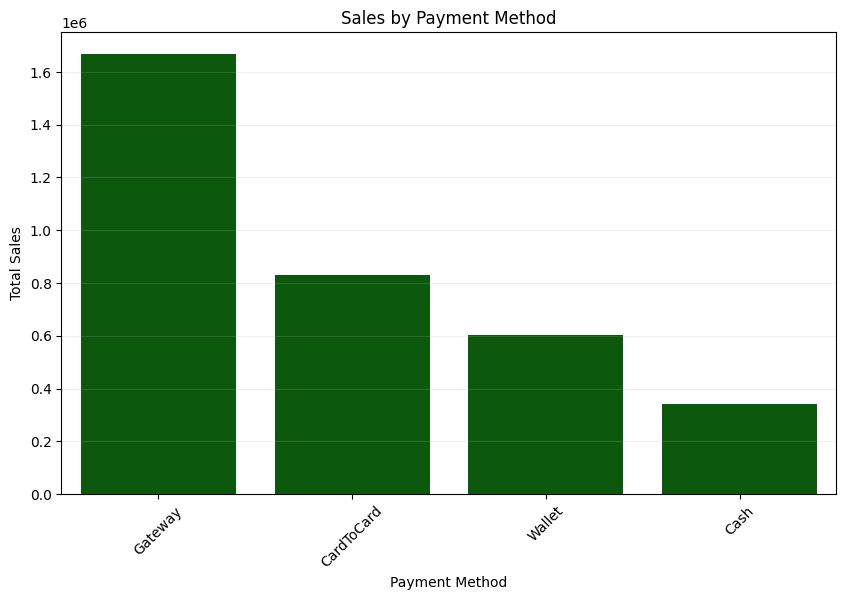

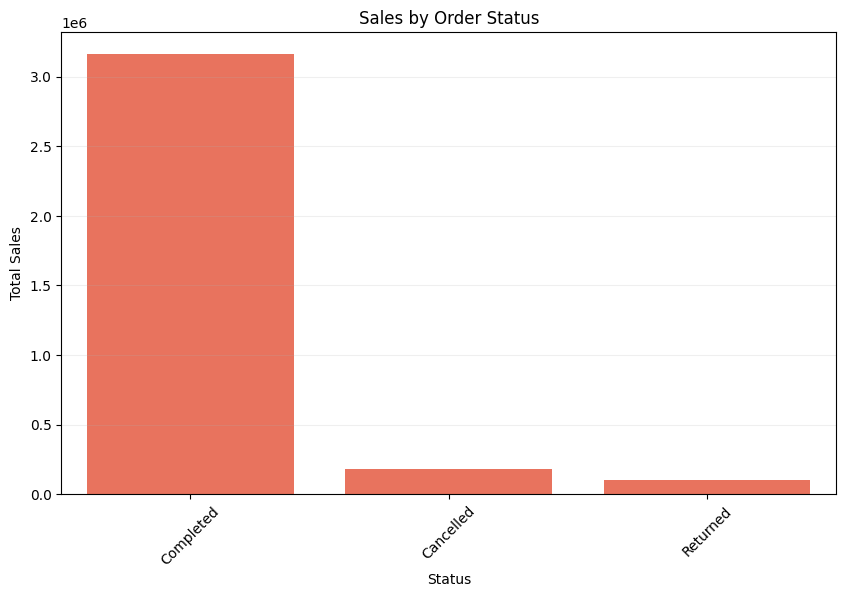

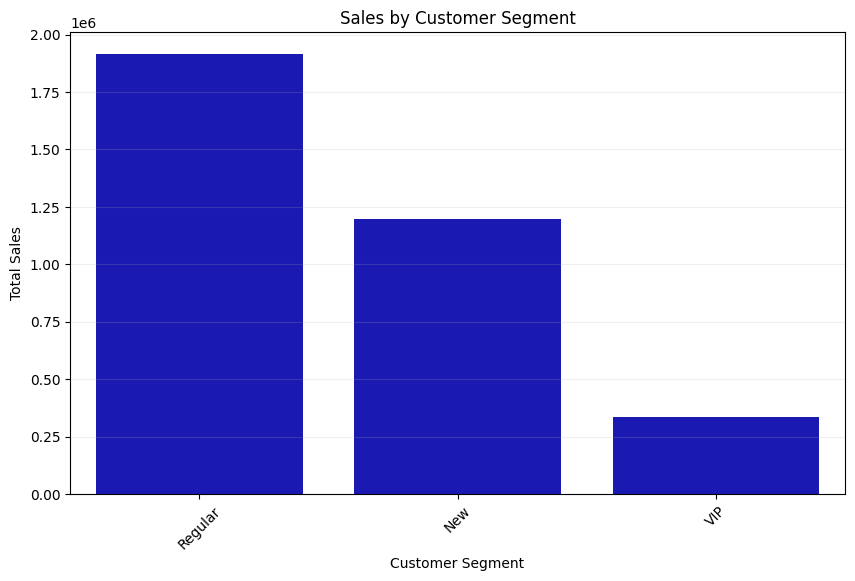

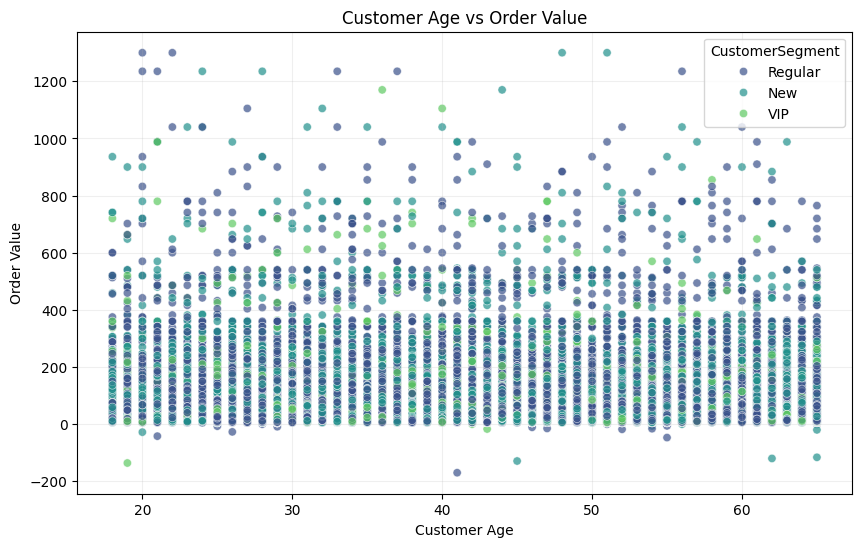

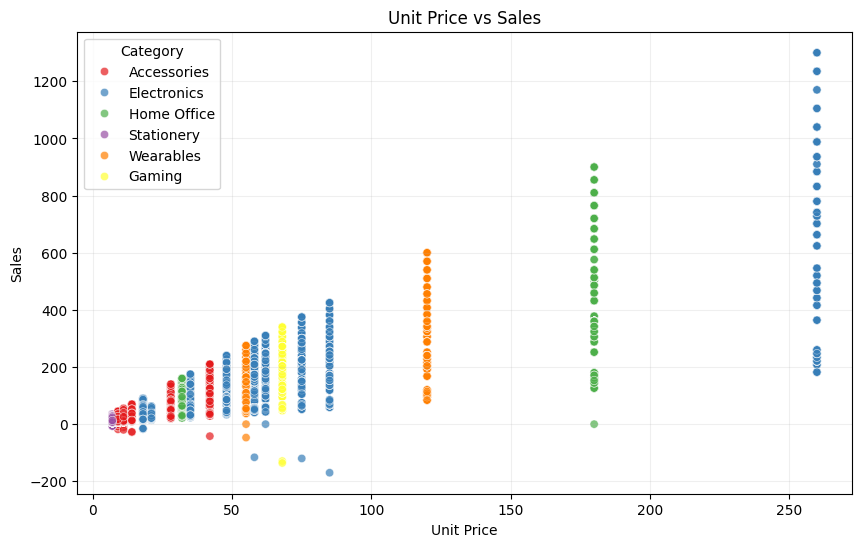

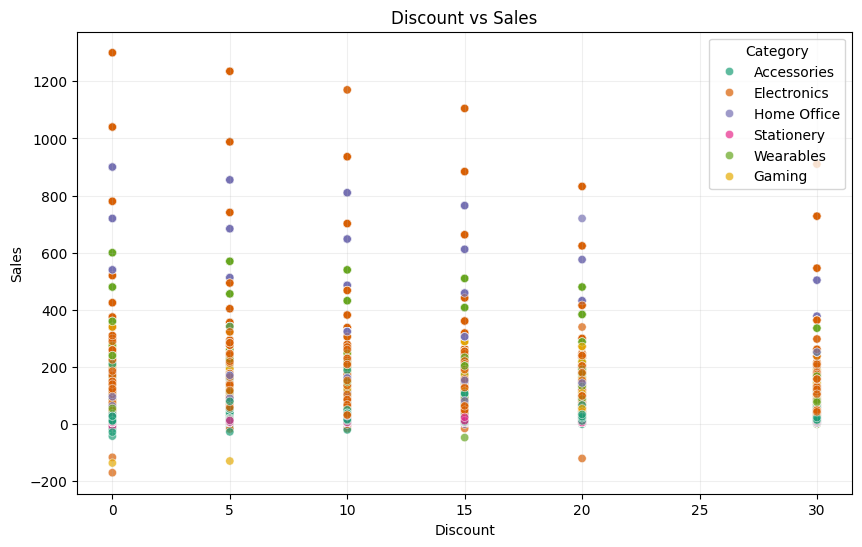

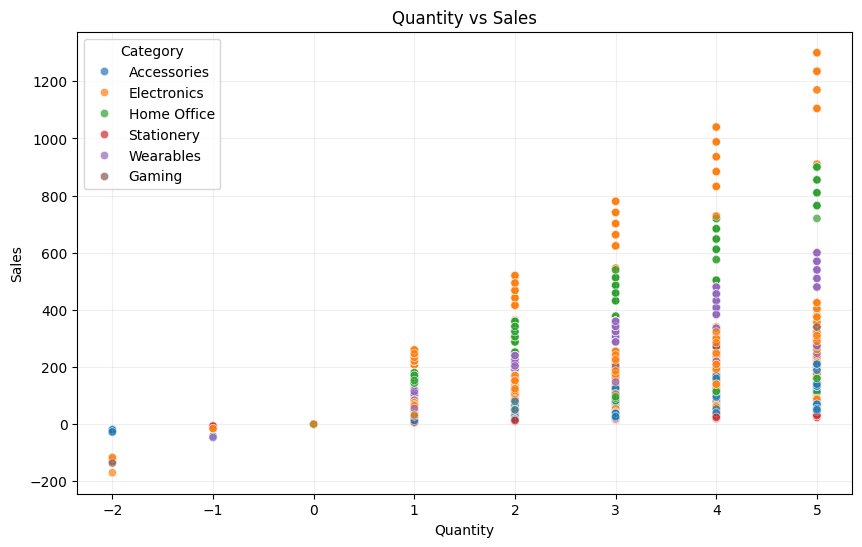

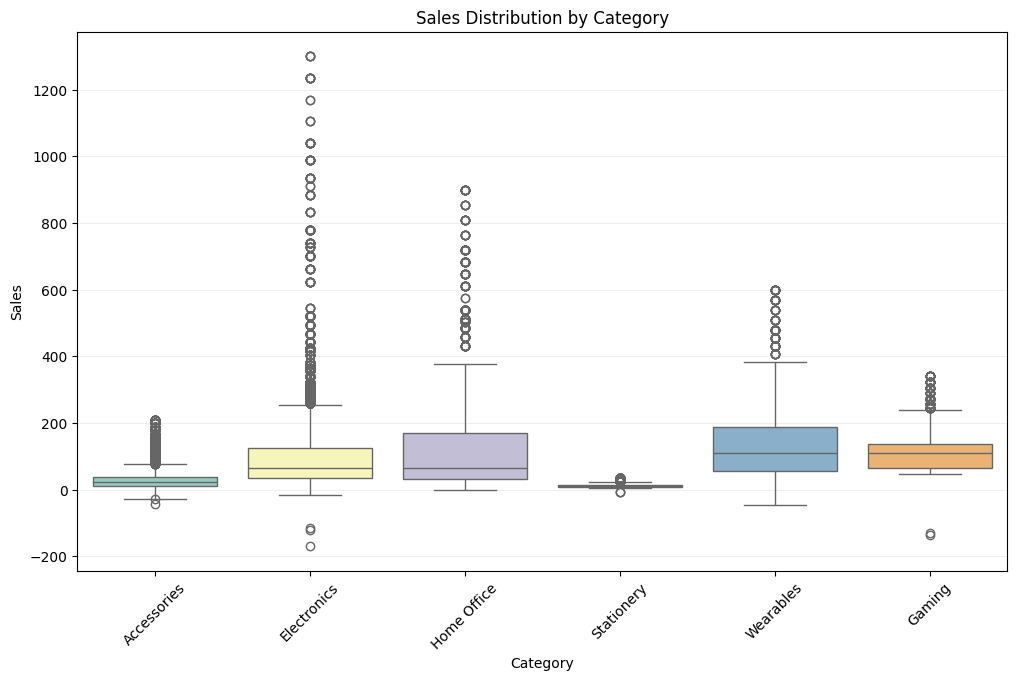

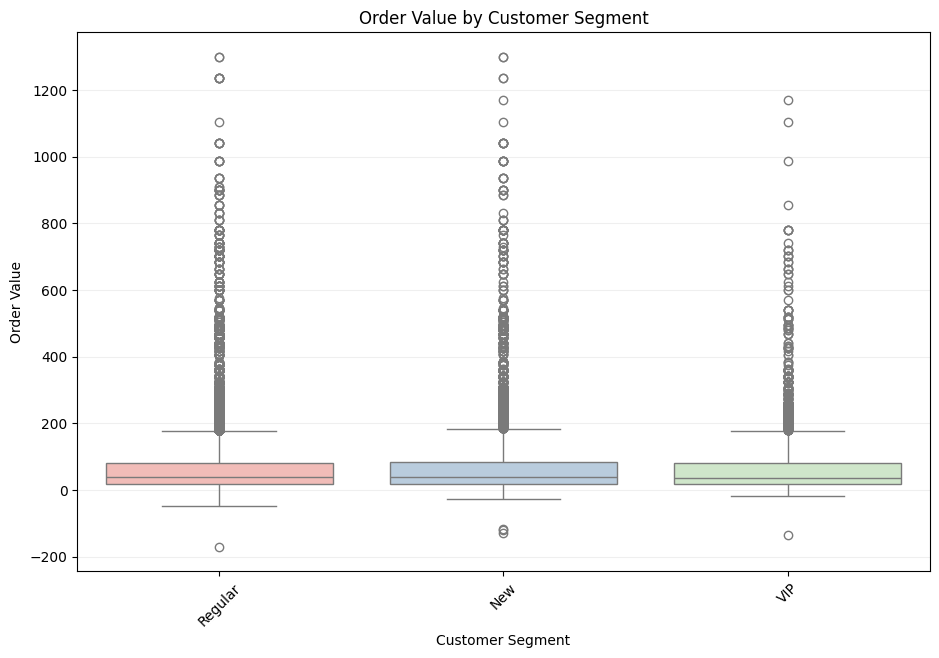

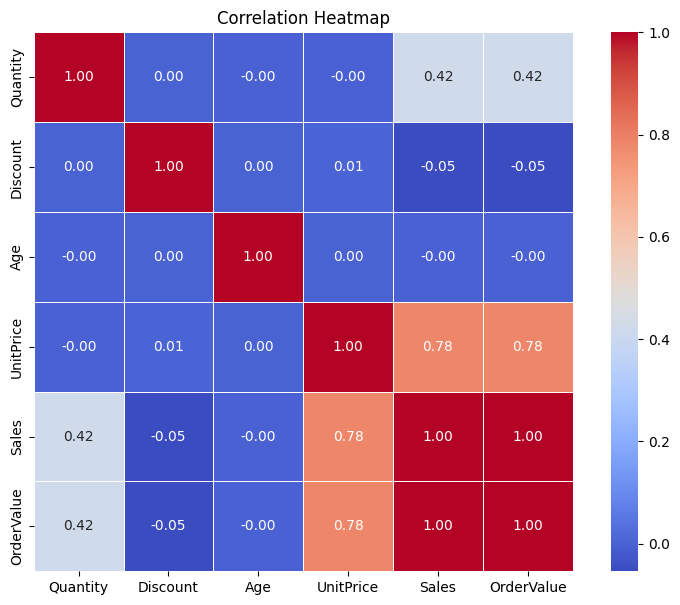

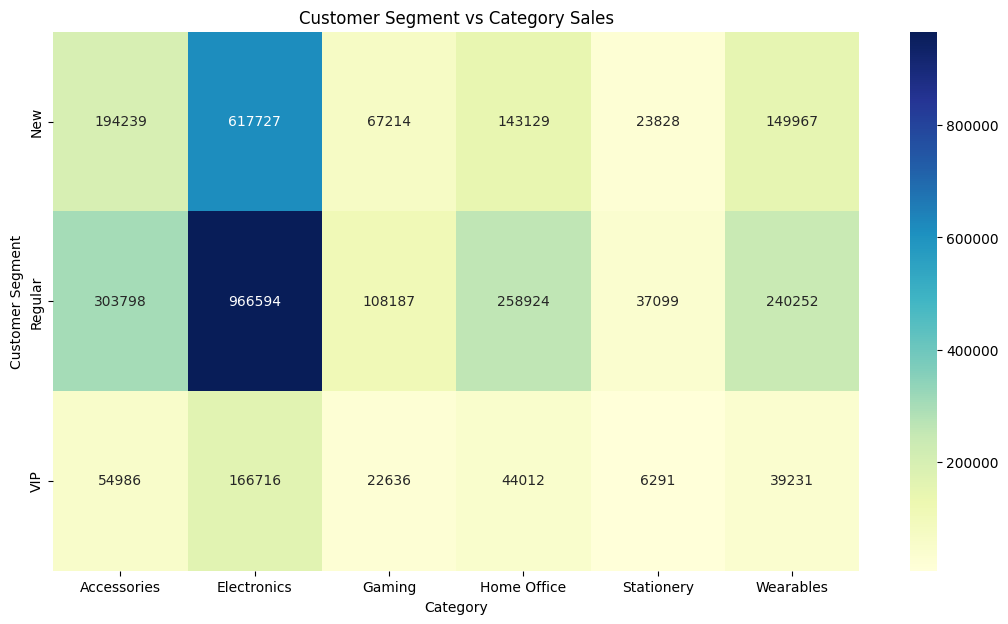

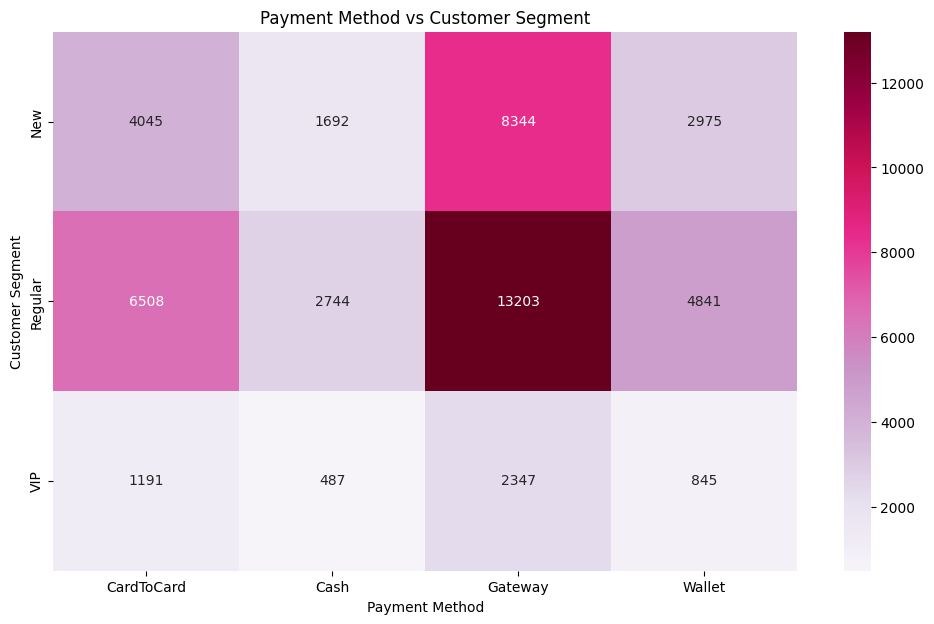

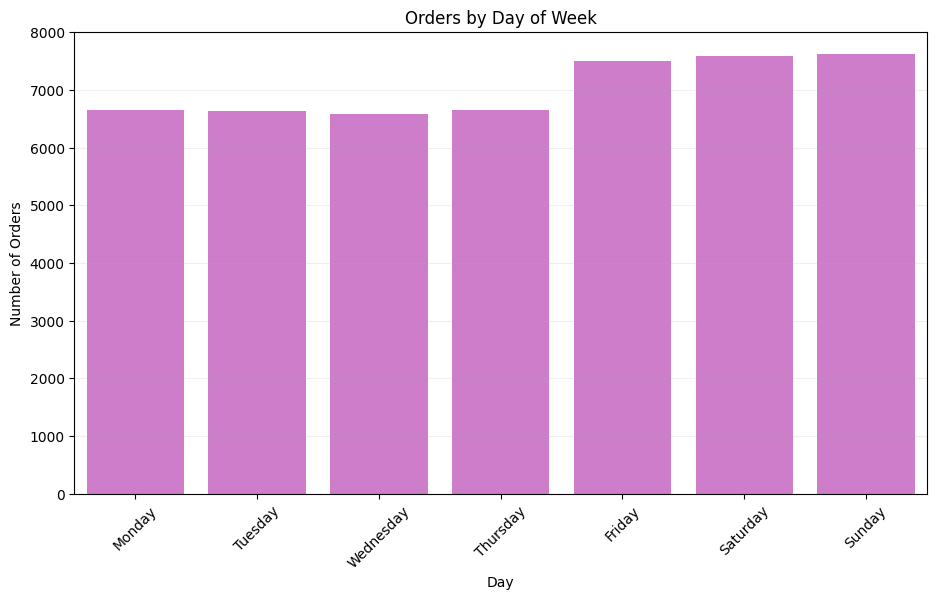

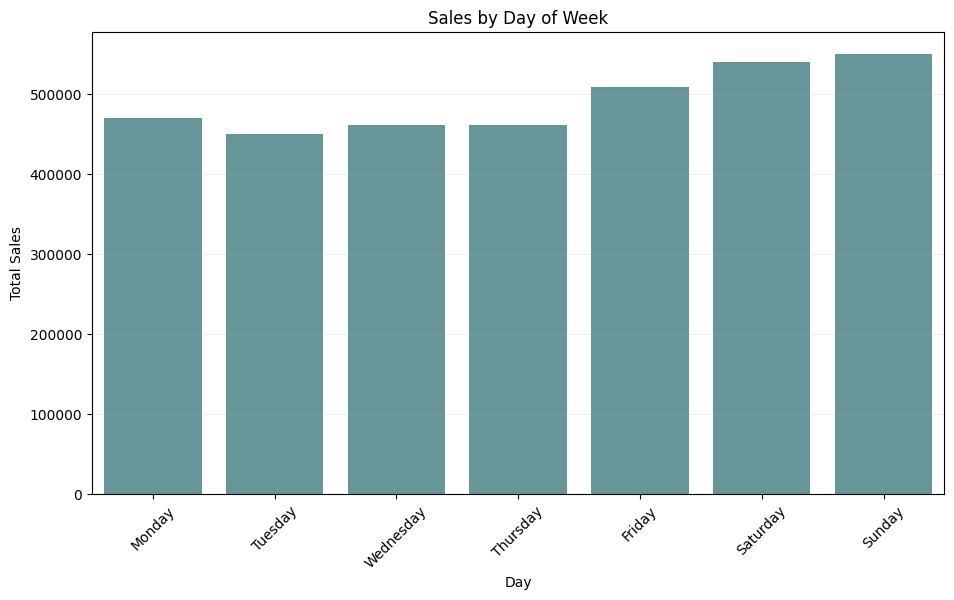


BUSINESS SUMMARY
Total Orders       : 49222
Total Customers    : 9820
Total Products     : 20
Total Quantity     : 92632.0
Total Sales        : 3444830.0
Total Order Value  : 3444830.0
Average Sales      : 69.99
Average OrderValue : 69.99
Average Discount   : 7.49
Average Age        : 41.28

Best Category by Sales: Electronics
Best Product by Sales: Headphones
Best City by Sales: Tehran
Most Used Payment Method: Gateway
Most Common Customer Segment: Regular

VISUALIZATION COMPLETED SUCCESSFULLY


In [13]:

import plotly.express as px
# Convert date columns
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    errors="coerce"
)

df["SignupDate"] = pd.to_datetime(
    df["SignupDate"],
    errors="coerce"
)

# Create useful date columns
df["OrderYear"] = df["OrderDate"].dt.year
df["OrderMonth"] = df["OrderDate"].dt.month
df["OrderMonthName"] = df["OrderDate"].dt.strftime("%b")
df["OrderQuarter"] = df["OrderDate"].dt.quarter
df["OrderDay"] = df["OrderDate"].dt.day_name()


# ============================================================
# 5. NUMERICAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("NUMERICAL SUMMARY")
print("=" * 70)

print(
    df[
        [
            "Quantity",
            "Discount",
            "Age",
            "UnitPrice",
            "Sales",
            "OrderValue"
        ]
    ].describe()
)


# ============================================================
# 6. SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Sales"].dropna(),
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 7. ORDER VALUE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["OrderValue"].dropna(),
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 8. CUSTOMER AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Age"].dropna(),
    bins=25,
    kde=True,
    color="mediumseagreen"
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 9. DISCOUNT DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Discount"].dropna(),
    bins=20,
    kde=True,
    color="crimson"
)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 10. QUANTITY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Quantity",
    color="purple"
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 11. PAYMENT METHOD DISTRIBUTION
# ============================================================

payment_counts = df["PaymentMethod"].value_counts()

plt.figure(figsize=(9, 6))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(payment_counts))
)

plt.title("Payment Method Distribution")
plt.show()


# ============================================================
# 12. ORDER STATUS DISTRIBUTION
# ============================================================

status_counts = df["Status"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    color="teal"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 13. CUSTOMER SEGMENT DISTRIBUTION
# ============================================================

segment_counts = df["CustomerSegment"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    color="mediumorchid"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 14. CATEGORY DISTRIBUTION
# ============================================================

category_counts = df["Category"].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    color="coral"
)

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 15. CATEGORY-WISE SALES
# ============================================================

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    color="steelblue"
)

plt.title("Category-wise Total Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 16. CATEGORY-WISE ORDER VALUE
# ============================================================

category_order_value = (
    df.groupby("Category")["OrderValue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_order_value.index,
    y=category_order_value.values,
    color="goldenrod"
)

plt.title("Category-wise Order Value")
plt.xlabel("Category")
plt.ylabel("Total Order Value")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 17. CATEGORY-WISE QUANTITY
# ============================================================

category_quantity = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values,
    color="seagreen"
)

plt.title("Category-wise Quantity Sold")
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 18. TOP 10 PRODUCTS BY SALES
# ============================================================

top_products = (
    df.groupby("ProductName")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    color="slateblue"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.2)
plt.show()


# ============================================================
# 19. TOP 10 PRODUCTS BY QUANTITY
# ============================================================

top_quantity_products = (
    df.groupby("ProductName")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_quantity_products.values,
    y=top_quantity_products.index,
    color="darkcyan"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.grid(axis="x", alpha=0.2)
plt.show()


# ============================================================
# 20. TOP 10 CITIES BY SALES
# ============================================================

top_cities = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    color="firebrick"
)

plt.title("Top 10 Cities by Sales")
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.grid(axis="x", alpha=0.2)
plt.show()


# ============================================================
# 21. TOP 10 CUSTOMERS BY SALES
# ============================================================

top_customers = (
    df.groupby("CustomerID")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str),
    color="darkviolet"
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")
plt.grid(axis="x", alpha=0.2)
plt.show()


# ============================================================
# 22. SALES TREND OVER TIME
# ============================================================

daily_sales = (
    df.groupby("OrderDate")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_sales,
    x="OrderDate",
    y="Sales",
    color="royalblue",
    linewidth=2
)

plt.title("Daily Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 23. MONTHLY SALES
# ============================================================

monthly_sales = (
    df.groupby("OrderMonth")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=monthly_sales,
    x="OrderMonth",
    y="Sales",
    marker="o",
    color="darkorange",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 24. YEARLY SALES
# ============================================================

yearly_sales = (
    df.groupby("OrderYear")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=yearly_sales,
    x="OrderYear",
    y="Sales",
    color="mediumseagreen"
)

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 25. QUARTER-WISE SALES
# ============================================================

quarter_sales = (
    df.groupby("OrderQuarter")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=quarter_sales,
    x="OrderQuarter",
    y="Sales",
    color="indianred"
)

plt.title("Quarter-wise Sales")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["Q1", "Q2", "Q3", "Q4"]
)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 26. SALES BY PAYMENT METHOD
# ============================================================

payment_sales = (
    df.groupby("PaymentMethod")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values,
    color="darkgreen"
)

plt.title("Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 27. SALES BY ORDER STATUS
# ============================================================

status_sales = (
    df.groupby("Status")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=status_sales.index,
    y=status_sales.values,
    color="tomato"
)

plt.title("Sales by Order Status")
plt.xlabel("Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 28. CUSTOMER SEGMENT VS SALES
# ============================================================

segment_sales = (
    df.groupby("CustomerSegment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values,
    color="mediumblue"
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 29. CUSTOMER AGE VS ORDER VALUE
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="OrderValue",
    hue="CustomerSegment",
    palette="viridis",
    alpha=0.7
)

plt.title("Customer Age vs Order Value")
plt.xlabel("Customer Age")
plt.ylabel("Order Value")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 30. UNIT PRICE VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="UnitPrice",
    y="Sales",
    hue="Category",
    palette="Set1",
    alpha=0.7
)

plt.title("Unit Price vs Sales")
plt.xlabel("Unit Price")
plt.ylabel("Sales")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 31. DISCOUNT VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Sales",
    hue="Category",
    palette="Dark2",
    alpha=0.7
)

plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Sales")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 32. QUANTITY VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales",
    hue="Category",
    palette="tab10",
    alpha=0.7
)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 33. BOX PLOT - SALES BY CATEGORY
# ============================================================

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df,
    x="Category",
    y="Sales",
    hue="Category",
    palette="Set3",
    legend=False
)

plt.title("Sales Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 34. BOX PLOT - ORDER VALUE BY CUSTOMER SEGMENT
# ============================================================

plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df,
    x="CustomerSegment",
    y="OrderValue",
    hue="CustomerSegment",
    palette="Pastel1",
    legend=False
)

plt.title("Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 35. CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Quantity",
    "Discount",
    "Age",
    "UnitPrice",
    "Sales",
    "OrderValue"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap")
plt.show()


# ============================================================
# 36. CUSTOMER SEGMENT + CATEGORY SALES
# ============================================================

segment_category = pd.pivot_table(
    df,
    values="Sales",
    index="CustomerSegment",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(13, 7))

sns.heatmap(
    segment_category,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Customer Segment vs Category Sales")
plt.xlabel("Category")
plt.ylabel("Customer Segment")
plt.show()


# ============================================================
# 37. PAYMENT METHOD + CUSTOMER SEGMENT
# ============================================================

payment_segment = pd.crosstab(
    df["CustomerSegment"],
    df["PaymentMethod"]
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    payment_segment,
    annot=True,
    fmt="d",
    cmap="PuRd"
)

plt.title("Payment Method vs Customer Segment")
plt.xlabel("Payment Method")
plt.ylabel("Customer Segment")
plt.show()


# ============================================================
# 38. ORDER DAY ANALYSIS
# ============================================================

day_order = (
    df["OrderDay"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=day_order.index,
    y=day_order.values,
    color="orchid"
)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 39. SALES BY DAY OF WEEK
# ============================================================

day_sales = (
    df.groupby("OrderDay")["Sales"]
    .sum()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

plt.figure(figsize=(11, 6))

sns.barplot(
    x=day_sales.index,
    y=day_sales.values,
    color="cadetblue"
)

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()


# ============================================================
# 40. INTERACTIVE CATEGORY SALES - PLOTLY
# ============================================================

interactive_category = (
    df.groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values("Sales", ascending=False)
)

fig = px.bar(
    interactive_category,
    x="Category",
    y="Sales",
    title="Interactive Category-wise Sales",
    color="Category"
)

fig.update_layout(
    xaxis_title="Category",
    yaxis_title="Total Sales"
)

fig.show()


# ============================================================
# 41. INTERACTIVE MONTHLY SALES
# ============================================================

interactive_monthly = (
    df.groupby("OrderMonth", as_index=False)["Sales"]
    .sum()
)

fig = px.line(
    interactive_monthly,
    x="OrderMonth",
    y="Sales",
    markers=True,
    title="Interactive Monthly Sales Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Sales"
)

fig.show()


# ============================================================
# 42. INTERACTIVE AGE VS ORDER VALUE - FIXED
# ============================================================

import plotly.express as px
import pandas as pd

# Make sure numeric columns are numeric
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["OrderValue"] = pd.to_numeric(df["OrderValue"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

# Remove missing values
plot_df = df.dropna(
    subset=[
        "Age",
        "OrderValue",
        "Quantity",
        "CustomerSegment"
    ]
).copy()

# ------------------------------------------------------------
# IMPORTANT:
# Plotly marker size cannot contain negative values.
# Convert Quantity to positive values.
# ------------------------------------------------------------
plot_df["Quantity_Size"] = plot_df["Quantity"].abs()

# Avoid zero-size markers
plot_df["Quantity_Size"] = plot_df["Quantity_Size"].clip(lower=1)

# Create interactive scatter plot
fig = px.scatter(
    plot_df,
    x="Age",
    y="OrderValue",
    color="CustomerSegment",
    size="Quantity_Size",
    hover_data=[
        "CustomerID",
        "ProductName",
        "Category",
        "City",
        "Quantity",
        "Sales",
        "UnitPrice",
        "Discount"
    ],
    title="Interactive Customer Age vs Order Value",
    labels={
        "Age": "Customer Age",
        "OrderValue": "Order Value",
        "Quantity_Size": "Quantity"
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=650,
    title_x=0.5
)

fig.show()


# ============================================================
# 43. FINAL BUSINESS SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("BUSINESS SUMMARY")
print("=" * 70)

print("Total Orders       :", df["OrderID"].nunique())
print("Total Customers    :", df["CustomerID"].nunique())
print("Total Products     :", df["ProductID"].nunique())
print("Total Quantity     :", df["Quantity"].sum())
print("Total Sales        :", round(df["Sales"].sum(), 2))
print("Total Order Value  :", round(df["OrderValue"].sum(), 2))
print("Average Sales      :", round(df["Sales"].mean(), 2))
print("Average OrderValue :", round(df["OrderValue"].mean(), 2))
print("Average Discount   :", round(df["Discount"].mean(), 2))
print("Average Age        :", round(df["Age"].mean(), 2))


# ============================================================
# 44. TOP PERFORMING CATEGORY
# ============================================================

best_category = (
    df.groupby("Category")["Sales"]
    .sum()
    .idxmax()
)

print("\nBest Category by Sales:", best_category)


# ============================================================
# 45. TOP PERFORMING PRODUCT
# ============================================================

best_product = (
    df.groupby("ProductName")["Sales"]
    .sum()
    .idxmax()
)

print("Best Product by Sales:", best_product)


# ============================================================
# 46. TOP CITY
# ============================================================

best_city = (
    df.groupby("City")["Sales"]
    .sum()
    .idxmax()
)

print("Best City by Sales:", best_city)


# ============================================================
# 47. MOST USED PAYMENT METHOD
# ============================================================

best_payment = df["PaymentMethod"].mode()[0]

print("Most Used Payment Method:", best_payment)


# ============================================================
# 48. MOST COMMON CUSTOMER SEGMENT
# ============================================================

best_segment = df["CustomerSegment"].mode()[0]

print("Most Common Customer Segment:", best_segment)

print("\n" + "=" * 70)
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("=" * 70)

## Feature Engineering

In [14]:
X = df.drop(columns=['OrderValue']).copy()
y = df['OrderValue'].copy()

In [15]:
for col in ['OrderDate', 'SignupDate']:
    X[col] = pd.to_datetime(X[col], errors='coerce')
    X[col + '_Year'] = X[col].dt.year
    X[col + '_Month'] = X[col].dt.month
    X[col + '_Day'] = X[col].dt.day
    X[col + '_DayOfWeek'] = X[col].dt.dayofweek
    X.drop(columns=[col], inplace=True)

In [16]:
X.drop(columns=['OrderID', 'CustomerID', 'ProductID'], errors='ignore', inplace=True)

In [17]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

In [18]:
preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [20]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        n_jobs=-1,
        random_state=42
    ))
])

In [21]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['Quantity', 'Discount', 'Age', 'UnitPrice', 'Sales', 'OrderYear',
       'OrderMonth', 'OrderQuarter', 'OrderDate_Year', 'OrderDate_Month',
       'OrderDate_Day', 'OrderDate_DayOfWeek', 'SignupDate_Year',
       'SignupDate_Month', 'SignupDate_Day', 'SignupDate_DayOfWeek'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['PaymentMethod', 'Status', 'City', 'CustomerSegment', 'ProductName',
       'Category', 'OrderMonthName', 'OrderDay'],
      dtype='object'))])),
                ('regressor',
                 ExtraTreesRegressor(n_estimators=300, n_jobs=-1,
                                     random_state=42))])

In [22]:
y_pred = model.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.2%}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 99.96%
MAE: 0.04
RMSE: 1.82


## Thank you...pls upvote!!!!!!!!!